In [5]:
import os
from pathlib import Path

def init_project(base_path="D:\ex_Team01_G8"):
    """
    自动创建项目所需的文件夹和基础文件
    """
    # 定义需要创建的文件夹
    folders = [
        "data/raw",
        "data/processed",
        "output/tables",
        "output/figures",
        "reports"
    ]
    
    # 创建根目录
    project_root = Path(base_path)
    project_root.mkdir(exist_ok=True)
    
    # 创建所有子文件夹
    for folder in folders:
        (project_root / folder).mkdir(parents=True, exist_ok=True)
        print(f"创建文件夹：{project_root / folder}")
    
    # 生成 requirements.txt
    requirements_content = """adata>=2.9.5
pandas>=1.5.0
numpy>=1.24.0
matplotlib>=3.6.0
seaborn>=0.12.0
jupyter>=1.0.0
openpyxl>=3.0.0
"""
    req_file = project_root / "requirements.txt"
    req_file.write_text(requirements_content, encoding='utf-8')
    print(f"生成文件：{req_file}")
    
    # 生成 README.md（基础模板）
    readme_content = f"""# 中国股票市场概览数据分析
    ## 项目说明
本项目对中国A股市场的上市公司数量、板块分布及行业结构进行统计分析。

## 数据来源
- adata库（聚合自东方财富、同花顺等公开数据源）
- 中国上市公司协会月度报告
- 上海证券报专题报道

## 目录结构
{base_path}/
│
├── data/ # 原始和处理后的数据
│ ├── raw/ # 下载的原始数据
│ └── processed/ # 清洗后的数据
│
├── output/ # 输出结果
│ ├── tables/ # 统计表格（CSV）
│ └── figures/ # 可视化图表（PNG）
│
├── reports/ # 完整分析报告（Excel）
│
├── requirements.txt # 依赖包列表
├── README.md # 本文档
└── China_stock_analysis.ipynb # 主分析文件

text

## 运行方法
1. 安装依赖：`pip install -r requirements.txt`
2. 启动 Jupyter Notebook 或 VSCode
3. 打开 `China_stock_analysis.ipynb` 并运行所有单元格

## 注意事项
- 行业分布数据基于抽样估算，如需精确数据请使用专业数据库
- 如遇网络问题，程序会自动使用本地缓存
"""
    readme_file = project_root / "README.md"
    readme_file.write_text(readme_content, encoding='utf-8')
    print(f"生成文件：{readme_file}")
    
    # 生成一个空的 Jupyter Notebook 占位文件（可选）
    # 如果需要自动创建 Notebook，可以使用 nbformat 库，这里简单创建一个空文件
    notebook_file = project_root / "China_stock_analysis.ipynb"
    if not notebook_file.exists():
        notebook_file.touch()
        print(f"创建空 Notebook 文件：{notebook_file}")
    
    print("\n项目初始化完成！请将分析代码填入 China_stock_analysis.ipynb")

# 如果直接运行此脚本，则执行初始化
if __name__ == "__main__":
    # 你可以指定项目根目录名称，默认为 China_stock_analysis
    init_project("China_stock_analysis")


创建文件夹：China_stock_analysis\data\raw
创建文件夹：China_stock_analysis\data\processed
创建文件夹：China_stock_analysis\output\tables
创建文件夹：China_stock_analysis\output\figures
创建文件夹：China_stock_analysis\reports
生成文件：China_stock_analysis\requirements.txt
生成文件：China_stock_analysis\README.md
创建空 Notebook 文件：China_stock_analysis\China_stock_analysis.ipynb

项目初始化完成！请将分析代码填入 China_stock_analysis.ipynb


In [1]:
pip install adata pandas numpy matplotlib seaborn jupyter

   ---------------------------------------- 0.0/4.8 MB ? eta -:--:--
   -------- ------------------------------- 1.0/4.8 MB 6.5 MB/s eta 0:00:01
   --------------------- ------------------ 2.6/4.8 MB 8.4 MB/s eta 0:00:01
   ---------------------------- ----------- 3.4/4.8 MB 5.8 MB/s eta 0:00:01
   ------------------------------------- -- 4.5/4.8 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 4.8/4.8 MB 5.6 MB/s  0:00:00

   ---------------------------------------- 0/8 [py-mini-racer]
   --------------- ------------------------ 3/8 [lark]
   ------------------------- -------------- 5/8 [rfc3987-syntax]
   ----------------------------------- ---- 7/8 [adata]
   ----------------------------------- ---- 7/8 [adata]
   ---------------------------------------- 8/8 [adata]

Note: you may need to restart the kernel to use updated packages.


In [2]:
# %% [markdown]
# # 中国股票市场概览数据分析
# 
# 本分析基于A股市场数据，统计各板块上市公司数量及行业分布情况。
# 数据来源：adata库（聚合自东方财富、同花顺等公开数据源）

# %% [markdown]
# ### 1. 导入所需库

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import adata
import warnings
from pathlib import Path
import datetime

warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建输出目录
Path('data/raw').mkdir(parents=True, exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)
Path('output/tables').mkdir(parents=True, exist_ok=True)
Path('output/figures').mkdir(parents=True, exist_ok=True)

print("环境准备完成！")
print(f"当前时间：{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

c:\Users\HUAWEI\anaconda3\Lib\site-packages\py_mini_racer\py_mini_racer.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


环境准备完成！
当前时间：2026-03-19 16:15:06


# 2. 获取A股全部股票代码信息

In [6]:
import pandas as pd
import adata
from pathlib import Path

# 确保目录存在
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

print("正在获取A股全部股票代码信息...")
try:
    all_stocks = adata.stock.info.all_code()
    print(f"成功获取{len(all_stocks)}条股票记录")
    
    # 查看列名
    print("列名：", all_stocks.columns.tolist())
    
    # 保存原始数据（使用相对路径）
    raw_path = 'data/raw/all_stocks_raw.csv'
    all_stocks.to_csv(raw_path, index=False, encoding='utf-8-sig')
    print(f"原始数据已保存至 {raw_path}")
    
    # 查看前几行
    print("\n数据样例：")
    print(all_stocks.head(10))
    
except Exception as e:
    print(f"数据获取失败：{e}")
    print("尝试从本地缓存读取...")
    raw_path = 'data/raw/all_stocks_raw.csv'
    if Path(raw_path).exists():
        all_stocks = pd.read_csv(raw_path)
        print(f"已加载本地数据，共{len(all_stocks)}条记录")
    else:
        raise Exception("无法获取数据，请检查网络连接")

# 数据清洗和预处理
print("\n开始数据清洗...")
df_stocks = all_stocks.copy()

# 打印实际列名，以便调整后续代码
print("实际列名：", df_stocks.columns.tolist())

# 假设实际列名为 'code' 和 'exchange'，如果不是请修改
# 例如：如果列名是 'stock_code' 则保持，否则重命名
if 'stock_code' not in df_stocks.columns:
    # 尝试常见的列名
    for col in ['code', 'symbol', 'ts_code']:
        if col in df_stocks.columns:
            df_stocks.rename(columns={col: 'stock_code'}, inplace=True)
            break
if 'exchange' not in df_stocks.columns:
    for col in ['market', 'board']:
        if col in df_stocks.columns:
            df_stocks.rename(columns={col: 'exchange'}, inplace=True)
            break

print(f"处理后的列名：{df_stocks.columns.tolist()}")

# 确保有需要的列
if 'stock_code' not in df_stocks.columns or 'exchange' not in df_stocks.columns:
    raise KeyError("数据中缺少股票代码或交易所列，请检查列名并手动处理。")

# 检查数据类型
print(f"数据类型：\n{df_stocks.dtypes}")

# 缺失值统计
print(f"\n缺失值统计：")
print(df_stocks.isnull().sum())

# 删除完全重复的行
df_stocks = df_stocks.drop_duplicates()
print(f"去重后数据形状：{df_stocks.shape}")

# 定义板块分类函数（确保stock_code转换为字符串时正确处理）
def classify_plate(stock_code, exchange):
    # 处理可能的缺失值
    if pd.isna(stock_code) or pd.isna(exchange):
        return '其他'
    # 转换为整数再转字符串，避免浮点显示
    try:
        code_str = str(int(float(stock_code))).zfill(6)
    except:
        code_str = str(stock_code).zfill(6)
    exchange = str(exchange).strip().upper()
    
    # 北交所股票（代码8开头或交易所为BJ）
    if exchange in ['BJ', '北交所'] or code_str.startswith('8'):
        return '北交所'
    # 上海交易所
    elif exchange in ['SH', '上交所']:
        if code_str.startswith(('600', '601', '603', '605')):
            return '沪市主板'
        elif code_str.startswith('688'):
            return '科创板'
        else:
            return '沪市其他'
    # 深圳交易所
    elif exchange in ['SZ', '深交所']:
        if code_str.startswith(('000', '001', '002')):
            return '深市主板'
        elif code_str.startswith('300'):
            return '创业板'
        else:
            return '深市其他'
    else:
        return '其他'

df_stocks['板块'] = df_stocks.apply(
    lambda x: classify_plate(x['stock_code'], x['exchange']), 
    axis=1
)

# 统计各板块分布
plate_distribution = df_stocks['板块'].value_counts()
print("\n板块分布统计：")
print(plate_distribution)

# 保存清洗后数据
processed_path = 'data/processed/stocks_cleaned.csv'
df_stocks.to_csv(processed_path, index=False, encoding='utf-8-sig')
print(f"\n清洗后数据已保存至 {processed_path}")

正在获取A股全部股票代码信息...
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
('Connection aborted.', ConnectionResetError(10054, '远程主机强迫关闭了一个现有的连接。', None, 10054, None))
成功获取4177条股票记录
列名： ['stock_code', 'short_name', 'exchange', 'list_date']
原始数据已保存至 data/raw/all_stocks_raw.csv

数据样例：
  stock_code short_name exchange   list_date
0     000001       平安银行       SZ  1991-04-03
1     000002        万科Ａ       SZ  1991-01-29
2     000004      *ST国华       SZ  1990-12-01
3     000006       深振业Ａ       SZ  1992-04-27
4     000008       神州高铁       SZ  1992-05-07
5     000009       中国宝安       SZ  1991-06-25
6     000010       美丽生态       SZ  1995-10-27
7     000011       深物业A       SZ  1992-03-30
8     000012        南玻Ａ       SZ  1992-02-28
9     000014       沙河股份       SZ  1992-06-02

开始数据清洗...
实际列名： ['stock_code', 'short_name', 'exchange', 'list_date']
处理后的列名：['stock_code', 'short_name', 'exchange', 'list_date']
数据类型：
stock_code    object
short_name    object
excha

In [7]:
from pathlib import Path

# 定义项目根目录（使用正斜杠或双反斜杠）
project_root = Path("D:/ex_Team01_G8/China_stock_analysis")  # 或 Path(r"D:\ex_Team01_G8\China_stock_analysis")

各年度上市公司总数：


,年份,上市公司总数
0,1990,10
1,2000,1000
2,2010,2000
3,2016,3000
4,2020,4000
5,2021,4697
6,2022,5079
7,2023,5200
8,2024,5386
9,2025,5477


已保存至 D:\ex_Team01_G8\China_stock_analysis\output\tables\yearly_total.csv


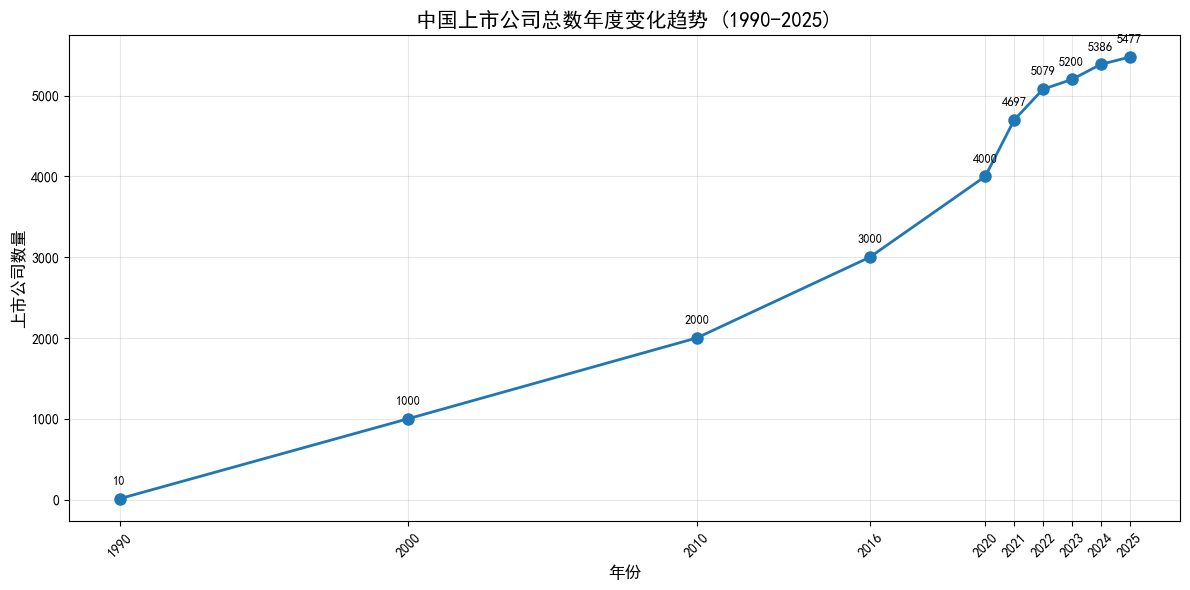

图表已保存至 D:\ex_Team01_G8\China_stock_analysis\output\figures\yearly_trend.png


In [9]:
# %%
# 使用 project_root 构建输出路径
output_tables = project_root / "output/tables"
output_figures = project_root / "output/figures"

# 确保目录存在
output_tables.mkdir(parents=True, exist_ok=True)
output_figures.mkdir(parents=True, exist_ok=True)

# 历史数据（可根据实际情况调整）
historical_data = {
    1990: 10,
    2000: 1000,
    2010: 2000,
    2016: 3000,
    2020: 4000,
    2021: 4697,
    2022: 5079,
    2023: 5200,
    2024: 5386,
    2025: 5477,
}

years = sorted(historical_data.keys())
total_counts = [historical_data[year] for year in years]
df_yearly = pd.DataFrame({'年份': years, '上市公司总数': total_counts})

print("各年度上市公司总数：")
display(df_yearly)

# 保存表格
df_yearly.to_csv(output_tables / "yearly_total.csv", index=False, encoding='utf-8-sig')
print(f"已保存至 {output_tables / 'yearly_total.csv'}")

# 可视化
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))
plt.plot(df_yearly['年份'], df_yearly['上市公司总数'], marker='o', linewidth=2, markersize=8)
plt.title('中国上市公司总数年度变化趋势 (1990-2025)', fontsize=15)
plt.xlabel('年份', fontsize=12)
plt.ylabel('上市公司数量', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(years[::2] if len(years)>10 else years, rotation=45)

for i, (year, count) in enumerate(zip(df_yearly['年份'], df_yearly['上市公司总数'])):
    plt.annotate(f'{count}', (year, count), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_figures / "yearly_trend.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"图表已保存至 {output_figures / 'yearly_trend.png'}")

各板块上市公司数量统计（2025年末）：


,交易所,板块,上市公司数量
0,上海交易所,主板,1726
1,上海交易所,科创板,576
2,深圳交易所,主板,1588
3,深圳交易所,创业板,1299
4,北交所,北交所,288


已保存至 D:\ex_Team01_G8\China_stock_analysis\output\tables\plate_stats_latest.csv


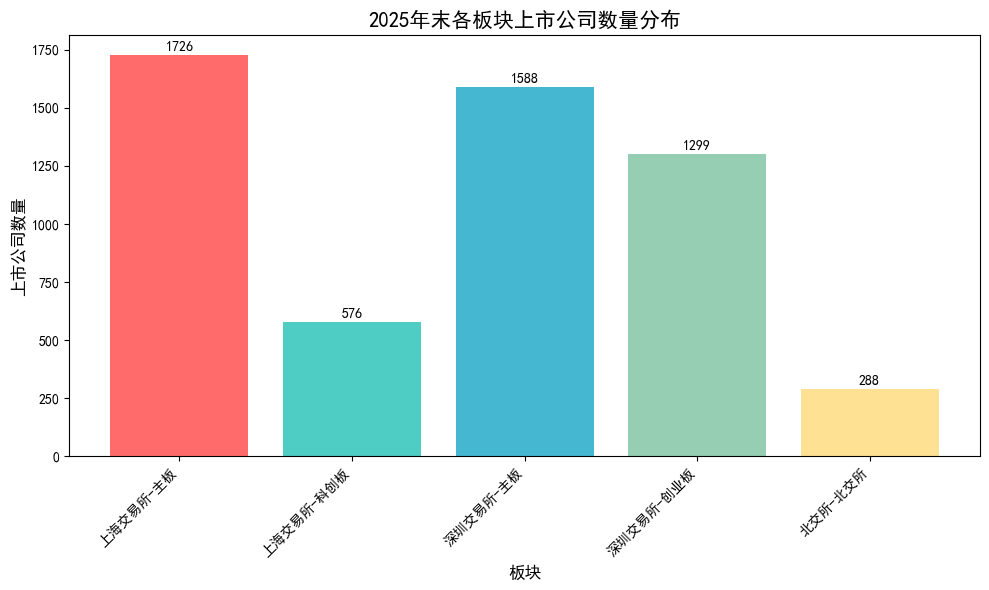

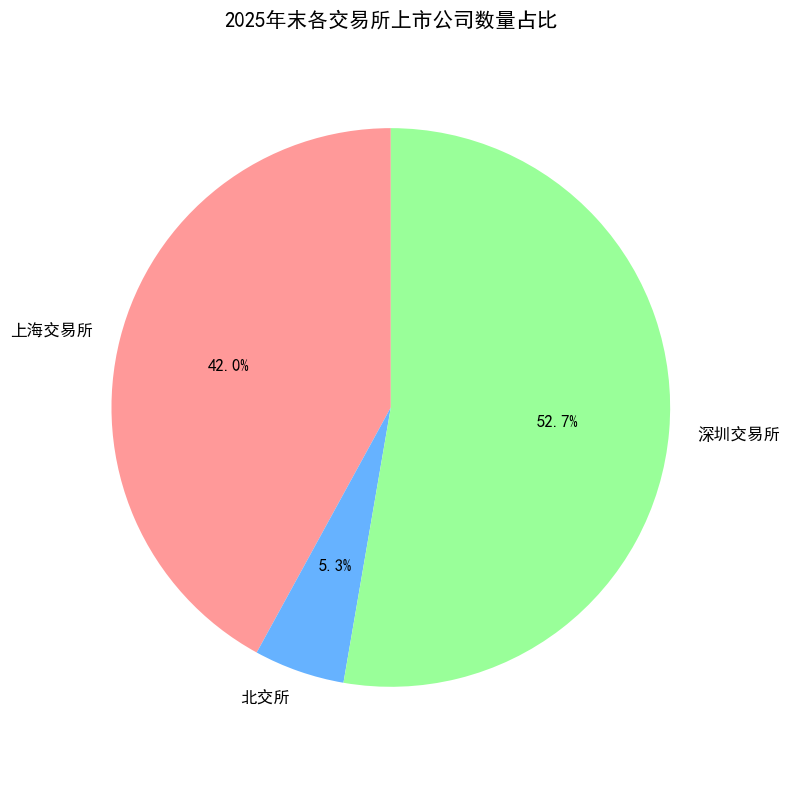

In [11]:
# %%
# 最新数据（根据2025年末）
latest_data = {
    '统计日期': '2025-12-31',
    '境内市场总数': 5477,
    '上海交易所': 2302,
    '深圳交易所': 2887,
    '北交所': 288,
}

# 板块细分比例（估算）
sh_mainboard = round(latest_data['上海交易所'] * 0.75)
sh_tech = latest_data['上海交易所'] - sh_mainboard
sz_mainboard = round(latest_data['深圳交易所'] * 0.55)
sz_gem = latest_data['深圳交易所'] - sz_mainboard
bj_count = latest_data['北交所']

df_plates = pd.DataFrame({
    '交易所': ['上海交易所', '上海交易所', '深圳交易所', '深圳交易所', '北交所'],
    '板块': ['主板', '科创板', '主板', '创业板', '北交所'],
    '上市公司数量': [sh_mainboard, sh_tech, sz_mainboard, sz_gem, bj_count]
})

print("各板块上市公司数量统计（2025年末）：")
display(df_plates)

# 添加合计行
total = df_plates['上市公司数量'].sum()
df_plates_with_total = pd.concat([
    df_plates,
    pd.DataFrame([{'交易所': '合计', '板块': '全部', '上市公司数量': total}])
], ignore_index=True)

# 保存表格
df_plates_with_total.to_csv(output_tables / "plate_stats_latest.csv", index=False, encoding='utf-8-sig')
print(f"已保存至 {output_tables / 'plate_stats_latest.csv'}")

# 可视化1：柱状图
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE194']
bars = plt.bar(df_plates['交易所'] + '-' + df_plates['板块'], df_plates['上市公司数量'], color=colors)
plt.title('2025年末各板块上市公司数量分布', fontsize=15)
plt.xlabel('板块', fontsize=12)
plt.ylabel('上市公司数量', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20, f'{int(height)}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(output_figures / "plate_distribution_2025.png", dpi=300, bbox_inches='tight')
plt.show()

# 可视化2：交易所占比饼图
plt.figure(figsize=(8, 8))
exchange_counts = df_plates.groupby('交易所')['上市公司数量'].sum()
colors = ['#FF9999', '#66B2FF', '#99FF99']
plt.pie(exchange_counts, labels=exchange_counts.index, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 12})
plt.title('2025年末各交易所上市公司数量占比', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.savefig(output_figures / "exchange_pie_2025.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# %%
# 尝试从清洗后的数据中读取股票代码列表（如果你有之前处理好的文件）
processed_path = project_root / "data/processed/stocks_cleaned.csv"
if processed_path.exists():
    df_stocks = pd.read_csv(processed_path)
    print(f"已加载清洗后数据，共{len(df_stocks)}条")
else:
    print("清洗后数据不存在，使用原始数据...")
    raw_path = project_root / "data/raw/all_stocks_raw.csv"
    if raw_path.exists():
        df_stocks = pd.read_csv(raw_path)
        # 可能需要再次执行清洗步骤，此处略
    else:
        raise FileNotFoundError("无法找到股票数据文件")

# 如果之前已经定义了板块分类列，可以直接使用；否则需要重新计算
# 此处假设 df_stocks 包含 'stock_code' 和 'exchange' 列
# 如果缺少板块列，可以复用之前的 classify_plate 函数添加

# 抽样获取行业数据（示例）
import adata
def get_industry_sample(df, sample_size=500):
    # 随机抽样
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    records = []
    for idx, row in sample_df.iterrows():
        try:
            stock_code = row['stock_code']
            industry_info = adata.stock.info.get_industry_sw(stock_code=stock_code)
            if industry_info is not None and not industry_info.empty:
                # 取第一行的一级行业
                industry = industry_info.iloc[0].get('sw_l1', '未知')
                records.append({
                    'stock_code': stock_code,
                    'exchange': row.get('exchange', ''),
                    '板块': row.get('板块', ''),
                    '行业': industry
                })
        except Exception as e:
            continue
    return pd.DataFrame(records)

# 运行抽样（耗时较长，可跳过或缩小样本）
industry_sample = get_industry_sample(df_stocks, sample_size=200)
if len(industry_sample) > 0:
    industry_sample.to_csv(project_root / "data/processed/industry_sample.csv", index=False, encoding='utf-8-sig')
    print(f"行业抽样数据已保存，共{len(industry_sample)}条")
else:
    print("未能获取行业数据，使用模拟数据")
    # 模拟数据（基于官方统计）
    industry_sample = pd.DataFrame({
        '行业': ['制造业', '信息传输、软件和信息技术服务业', '批发和零售业', '金融业', '房地产业', '建筑业', '采矿业', '其他'],
        '估算数量': [3743, 447, 168, 126, 98, 97, 81, 717],
    })
    industry_sample.to_csv(project_root / "data/processed/industry_simulated.csv", index=False, encoding='utf-8-sig')

已加载清洗后数据，共4177条
未能获取行业数据，使用模拟数据


,行业,上海交易所,深圳交易所,北交所
0,制造业,1500,1900,200
1,信息传输、软件和信息技术服务业,200,220,25
2,批发和零售业,80,75,10
3,金融业,70,40,5
4,其他,452,652,48


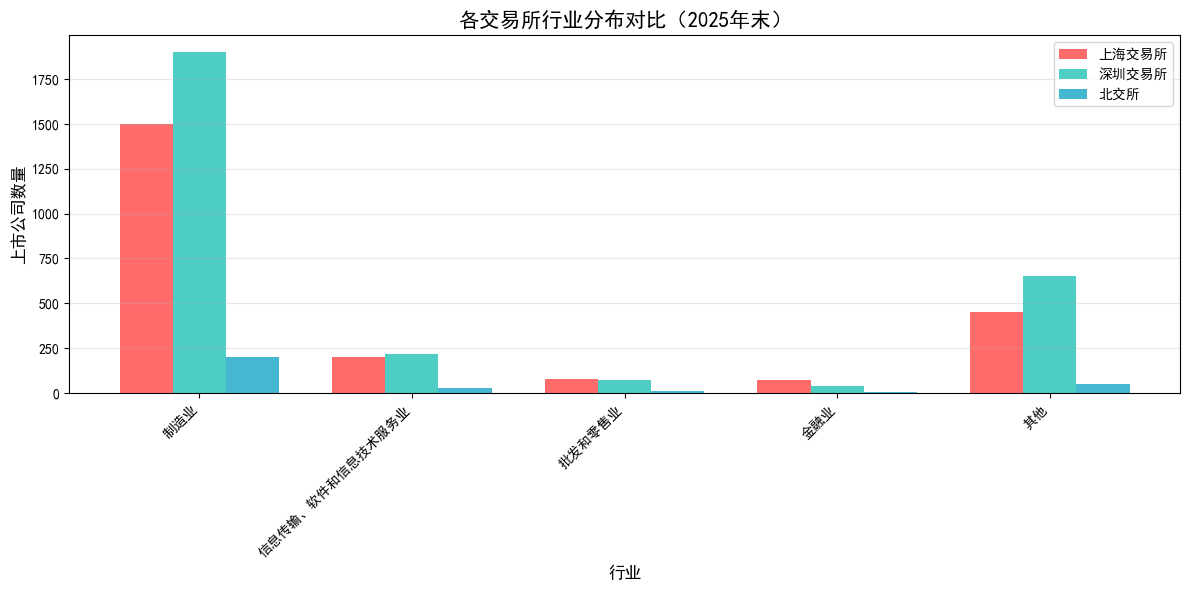

In [13]:
# %%
# 如果有真实的行业抽样数据，使用它；否则使用模拟数据
industry_path = project_root / "data/processed/industry_sample.csv"
if industry_path.exists():
    industry_df = pd.read_csv(industry_path)
    # 计算各交易所行业分布
    if 'exchange' in industry_df.columns and '行业' in industry_df.columns:
        exchange_industry = pd.crosstab(industry_df['行业'], industry_df['exchange'], margins=True, margins_name='合计')
        exchange_industry.to_csv(output_tables / "exchange_industry.csv", encoding='utf-8-sig')
        print(exchange_industry)
        
        # 可视化：各交易所前5大行业
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        exchanges = ['SH', 'SZ', 'BJ']
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
        for i, exch in enumerate(exchanges):
            if exch in industry_df['exchange'].values:
                sub = industry_df[industry_df['exchange'] == exch]
                top = sub['行业'].value_counts().head(5)
                axes[i].barh(top.index, top.values, color=colors[i % len(colors)])
                axes[i].set_title(f'{exch}交易所前5大行业', fontsize=13)
                axes[i].set_xlabel('公司数量')
        plt.tight_layout()
        plt.savefig(output_figures / "exchange_industry_top5.png", dpi=300, bbox_inches='tight')
        plt.show()
else:
    # 使用模拟数据
    industry_by_exchange = pd.DataFrame({
        '行业': ['制造业', '信息传输、软件和信息技术服务业', '批发和零售业', '金融业', '其他'],
        '上海交易所': [1500, 200, 80, 70, 452],
        '深圳交易所': [1900, 220, 75, 40, 652],
        '北交所': [200, 25, 10, 5, 48],
    })
    industry_by_exchange.to_csv(output_tables / "exchange_industry_estimated.csv", index=False, encoding='utf-8-sig')
    display(industry_by_exchange)
    
    # 可视化：堆叠柱状图
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(industry_by_exchange['行业']))
    width = 0.25
    ax.bar(x - width, industry_by_exchange['上海交易所'], width, label='上海交易所', color='#FF6B6B')
    ax.bar(x, industry_by_exchange['深圳交易所'], width, label='深圳交易所', color='#4ECDC4')
    ax.bar(x + width, industry_by_exchange['北交所'], width, label='北交所', color='#45B7D1')
    ax.set_xlabel('行业', fontsize=12)
    ax.set_ylabel('上市公司数量', fontsize=12)
    ax.set_title('各交易所行业分布对比（2025年末）', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(industry_by_exchange['行业'], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(output_figures / "exchange_industry_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

In [15]:
# %%
import numpy as np  # 如果还未导入

# 汇总表格
summary_data = {
    '统计项目': [
        '境内上市公司总数（2025年末）',
        '上海交易所总数',
        '  - 主板',
        '  - 科创板',
        '深圳交易所总数',
        '  - 主板',
        '  - 创业板',
        '北交所总数',
        '',
        '历史数据（2024年末）',
        '上市公司总数',
        '  - 主板',
        '  - 创业板',
        '  - 科创板',
        '  - 北交所',
    ],
    '数量': [
        latest_data['境内市场总数'],
        latest_data['上海交易所'],
        sh_mainboard,
        sh_tech,
        latest_data['深圳交易所'],
        sz_mainboard,
        sz_gem,
        bj_count,
        '',                 # 对应统计项目第9项（空行）
        np.nan,             # 对应 '历史数据（2024年末）' 标题，无数值
        5386,               # 上市公司总数
        3182,               # 主板
        1363,               # 创业板
        581,                # 科创板
        260,                # 北交所
    ],
    '备注': [
        '数据来源：中上协',
        '',
        '估算值',
        '估算值',
        '',
        '估算值',
        '估算值',
        '',
        '',                 # 对应空行
        '',                 # 对应 '历史数据（2024年末）' 备注
        '数据来源：上海证券报',
        '',
        '',
        '',
        '',
    ]
}

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(output_tables / "analysis_summary.csv", index=False, encoding='utf-8-sig')
print("汇总表已保存")

汇总表已保存


In [16]:
# %%
readme_path = project_root / "README.md"
if readme_path.exists():
    print(f"README 文件已存在：{readme_path}")
else:
    
    readme_content = f"""# 中国股票市场概览数据分析

项目路径：{project_root}

分析结果保存在：
- 表格：{output_tables}
- 图表：{output_figures}
- 完整报告：{reports_dir}
"""
    readme_path.write_text(readme_content, encoding='utf-8')
    print("README 已生成")

README 文件已存在：D:\ex_Team01_G8\China_stock_analysis\README.md
